# Tugas Proyek IF3211 - Domain-Specific Computation
## Deteksi Transisi Respirasi Aerobik-Anaerobik Berdasarkan Respiratory Exchange Ratio (RER) Menggunakan Arsitektur Long Short-Term Memory (LSTM)

**Anggota Kelompok:**
* 18223012 - Wilson
* 18223020 - Brandon Theodore Ferrinov
* 18223038 - Rafli Dwi Nugraga
* 18223090 - Derick Amadeus Budiono


Sumber Dataset : http://physionet.org/content/treadmill-exercise-cardioresp/1.0.1/

# 1. ***Library Import***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 2. ***LOAD DATA & PEMBUATAN TARGET***

In [2]:
df = pd.read_csv('datasets/test_measure.csv')

# [FIX #2] Gunakan 50 subjek (dibatasi untuk efisiensi komputasi)
# Hitung RER untuk seluruh dataset
df['RER'] = df['VCO2'] / df['VO2']
df['Anaerobic_Label'] = (df['RER'] >= 1.0).astype(int)

# Urutkan berdasarkan subjek dan waktu agar urutan temporal terjaga
df = df.sort_values(['ID_test', 'time']).reset_index(drop=True)

# Batasi ke 50 subjek pertama
selected_subjects = df['ID_test'].unique()[:50]
df = df[df['ID_test'].isin(selected_subjects)].reset_index(drop=True)

print(f"Total baris: {len(df)}")
print(f"Total subjek: {df['ID_test'].nunique()}")
print(f"Distribusi kelas:\n{df['Anaerobic_Label'].value_counts()}")


Total baris: 31361
Total subjek: 50
Distribusi kelas:
Anaerobic_Label
0    19136
1    12225
Name: count, dtype: int64


# 3. ***EXPLORATORY DATA ANALYSIS (EDA)***

Melakukan EDA


C:\Users\ASUS\AppData\Local\Temp\ipykernel_812\1119006970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anaerobic_Label', data=df, palette='Set2')


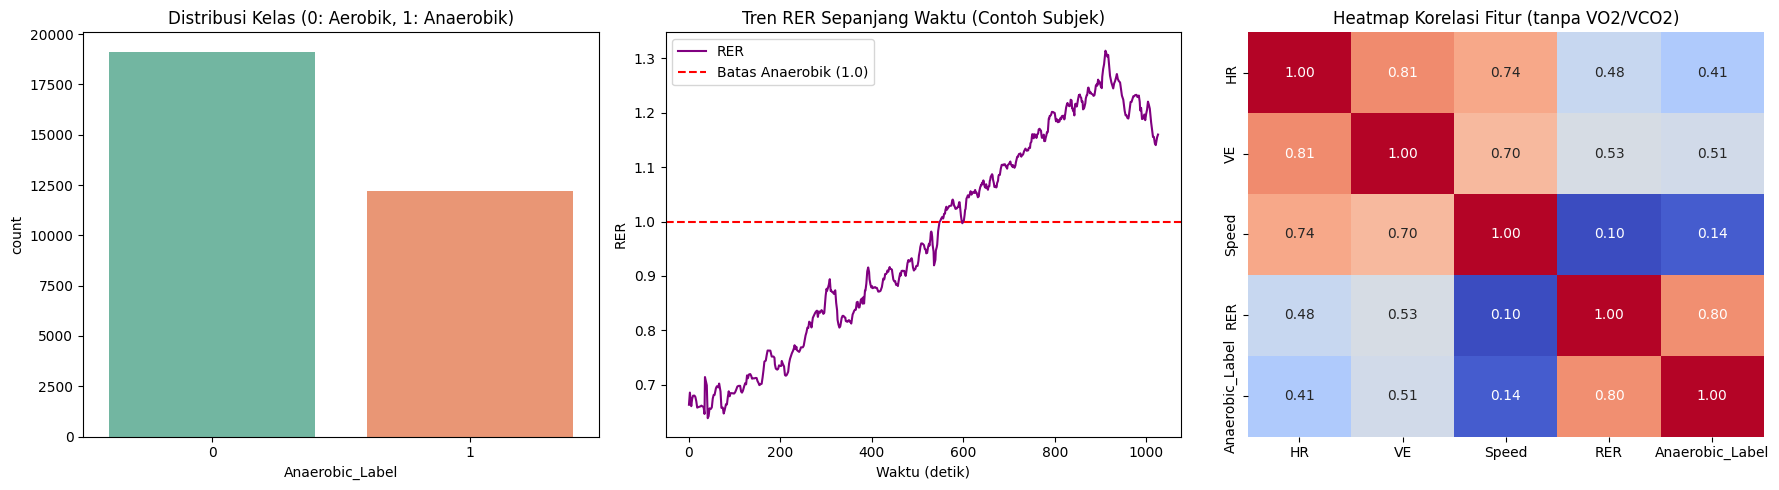

In [3]:
print("Melakukan EDA")

plt.figure(figsize=(18, 5))

# A. Distribusi Kelas Target
plt.subplot(1, 3, 1)
sns.countplot(x='Anaerobic_Label', data=df, palette='Set2')
plt.title('Distribusi Kelas (0: Aerobik, 1: Anaerobik)')

# B. Tren RER terhadap Waktu (contoh: subjek pertama)
plt.subplot(1, 3, 2)
df_sample = df[df['ID_test'] == df['ID_test'].unique()[0]]
plt.plot(df_sample['time'], df_sample['RER'], color='purple', label='RER')
plt.axhline(y=1.0, color='r', linestyle='--', label='Batas Anaerobik (1.0)')
plt.title('Tren RER Sepanjang Waktu (Contoh Subjek)')
plt.xlabel('Waktu (detik)')
plt.ylabel('RER')
plt.legend()

# C. Heatmap Korelasi Fitur
# [FIX #3] VO2/VCO2 ditampilkan di EDA tapi TIDAK dipakai sebagai fitur model
plt.subplot(1, 3, 3)
corr_cols = ['HR', 'VE', 'Speed', 'RER', 'Anaerobic_Label']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Heatmap Korelasi Fitur (tanpa VO2/VCO2)')

plt.tight_layout()
plt.show()


# 4. ***ADVANCED FEATURE ENGINEERING & PREPROCESSING***

In [ ]:
# [FIX #3] Hapus VO2 & VCO2 dari fitur — keduanya adalah komponen langsung RER
# (RER = VCO2/VO2), sehingga menyertakannya menyebabkan target leakage.

# Tambahkan Moving Average per subjek agar tidak bocor antar subjek
df['HR_MA'] = df.groupby('ID_test')['HR'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df['VE_MA'] = df.groupby('ID_test')['VE'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# [FIX #4] Tangani NaN di raw data SEBELUM membuat sequence
# ffill/bfill dilakukan per subjek agar tidak melewati batas antar-subjek
features = ['HR', 'HR_MA', 'VE', 'VE_MA', 'Speed']
for col in features:
    df[col] = df.groupby('ID_test')[col].transform(
        lambda x: x.ffill().bfill()
    )

# Pastikan tidak ada NaN tersisa
assert df[features].isnull().sum().sum() == 0, "Masih ada NaN di fitur setelah fillna!"
print("NaN di fitur setelah penanganan:", df[features].isnull().sum().sum())

# --- Bagi data menjadi train/test berdasarkan subjek (subject-wise split) ---
# [FIX #2 lanjutan] Karena data multi-subjek, split dilakukan di level subjek
# agar tidak ada data dari subjek yang sama di train sekaligus di test.
all_subjects = df['ID_test'].unique()
np.random.seed(42)
np.random.shuffle(all_subjects)

split_point = int(len(all_subjects) * 0.8)
train_subjects = all_subjects[:split_point]
test_subjects  = all_subjects[split_point:]

df_train = df[df['ID_test'].isin(train_subjects)].copy()
df_test  = df[df['ID_test'].isin(test_subjects)].copy()

print(f"Subjek train: {len(train_subjects)}, Subjek test: {len(test_subjects)}")

# [FIX #1] Fit scaler HANYA pada data train, lalu transform train & test
scaler = MinMaxScaler(feature_range=(0, 1))
df_train_scaled = scaler.fit_transform(df_train[features])
df_test_scaled  = scaler.transform(df_test[features])   # transform saja, tidak fit ulang

y_train_raw = df_train['Anaerobic_Label'].values
y_test_raw  = df_test['Anaerobic_Label'].values

# Sliding Window — dibuat per subjek agar tidak melewati batas antar-subjek
def create_sequences_per_subject(df_group, X_scaled_all, y_all, subject_col, time_steps):
    """Buat sequence per subjek untuk mencegah bocor antar batas subjek."""
    Xs, ys = [], []
    subjects = df_group[subject_col].unique()
    offset = 0
    for subj in subjects:
        mask = (df_group[subject_col] == subj).values
        n = mask.sum()
        X_subj = X_scaled_all[offset:offset + n]
        y_subj = y_all[offset:offset + n]
        offset += n
        for i in range(len(X_subj) - time_steps):
            Xs.append(X_subj[i:i + time_steps])
            ys.append(y_subj[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10

X_train, y_train = create_sequences_per_subject(
    df_train, df_train_scaled, y_train_raw, 'ID_test', time_steps
)
X_test, y_test = create_sequences_per_subject(
    df_test, df_test_scaled, y_test_raw, 'ID_test', time_steps
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"NaN di X_train: {np.isnan(X_train).sum()}, X_test: {np.isnan(X_test).sum()}")

print(f"Distribusi kelas y_train — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"Distribusi kelas y_test  — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}")


NaN di fitur setelah penanganan: 0
Subjek train: 40, Subjek test: 10
X_train shape: (25189, 10, 5), X_test shape: (5672, 10, 5)
NaN di X_train: 0, X_test: 0
Distribusi kelas y_train — 0: 15252, 1: 9937
Distribusi kelas y_test  — 0: 3395,  1: 2277


C:\Users\ASUS\AppData\Local\Temp\ipykernel_812\1464869152.py:29: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(all_subjects)


# 5. ***ADVANCED MODEL ARCHITECTURE (Bi-LSTM)***


In [6]:
# [FIX #6] Judul section diperbaiki: Bi-LTSM → Bi-LSTM
# Membangun ulang model untuk memastikan bobot diinisialisasi ulang
model = Sequential([
    # Layer Bidirectional LSTM pertama
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    # Layer Bidirectional LSTM kedua
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Menggunakan Adam optimizer dengan gradient clipping
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

print("\nMemulai Training Model Advanced Bi-LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,   # Pertahankan urutan temporal saat training
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)



Memulai Training Model Advanced Bi-LSTM...
Epoch 1/20
709/709 [==============================] - 13s 11ms/step - loss: 0.6339 - accuracy: 0.6394 - val_loss: 0.6862 - val_accuracy: 0.6995 - lr: 0.0010
Epoch 2/20
709/709 [==============================] - 6s 8ms/step - loss: 0.5107 - accuracy: 0.7459 - val_loss: 0.6561 - val_accuracy: 0.6737 - lr: 0.0010
Epoch 3/20
709/709 [==============================] - 6s 8ms/step - loss: 0.4617 - accuracy: 0.7742 - val_loss: 0.4491 - val_accuracy: 0.7836 - lr: 0.0010
Epoch 4/20
709/709 [==============================] - 6s 8ms/step - loss: 0.3972 - accuracy: 0.8147 - val_loss: 0.3296 - val_accuracy: 0.8547 - lr: 0.0010
Epoch 5/20
709/709 [==============================] - 6s 8ms/step - loss: 0.4021 - accuracy: 0.8163 - val_loss: 0.4054 - val_accuracy: 0.7932 - lr: 0.0010
Epoch 6/20
709/709 [==============================] - 6s 8ms/step - loss: 0.3659 - accuracy: 0.8370 - val_loss: 0.4508 - val_accuracy: 0.7293 - lr: 0.0010
Epoch 7/20
709/709 [====

# 6. ***EVALUASI***


Akurasi Testing (Advanced Model): 77.15%
178/178 [==============================] - 2s 3ms/step

--- Classification Report ---
               precision    recall  f1-score   support

  Aerobik (0)       0.86      0.74      0.79      3395
Anaerobik (1)       0.68      0.82      0.74      2277

     accuracy                           0.77      5672
    macro avg       0.77      0.78      0.77      5672
 weighted avg       0.79      0.77      0.77      5672



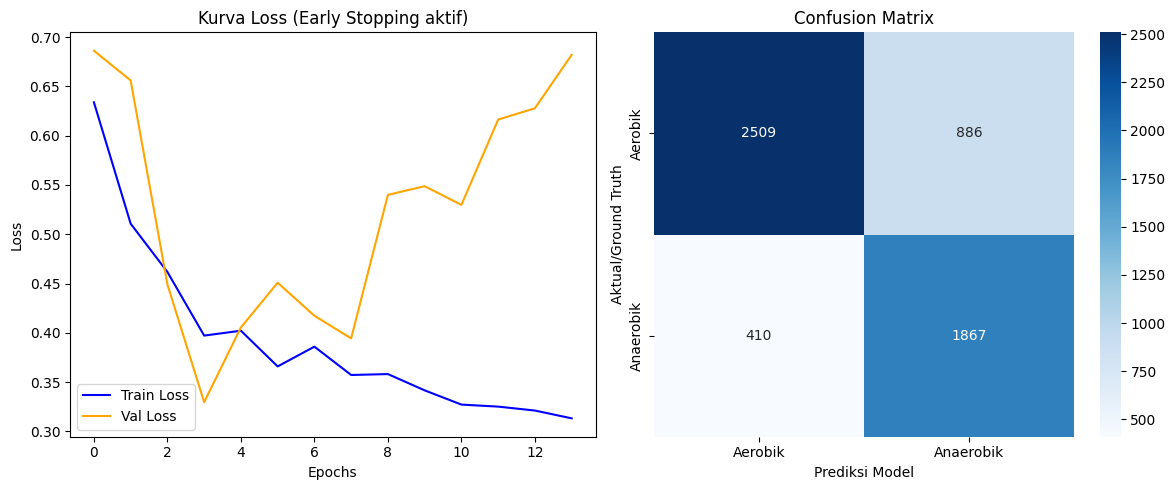

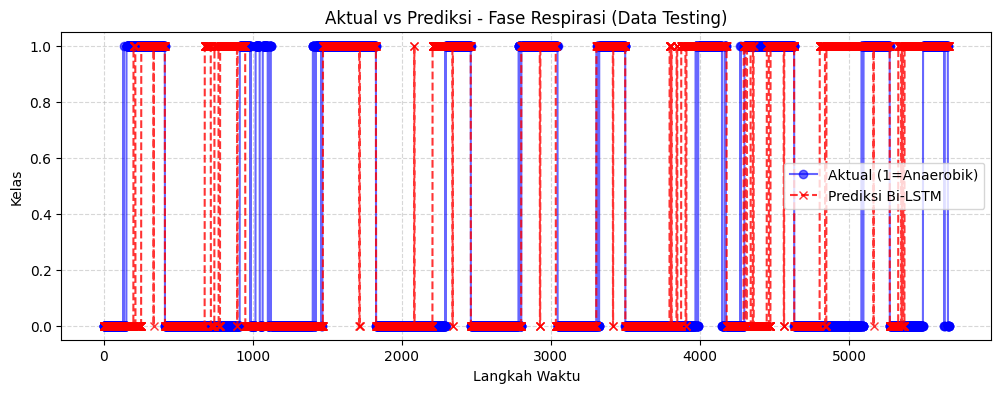

In [7]:
# Evaluasi Akurasi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Testing (Advanced Model): {test_acc * 100:.2f}%")

# Prediksi untuk Confusion Matrix & Classification Report
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Aerobik (0)', 'Anaerobik (1)']))

# Visualisasi Loss & Confusion Matrix
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Kurva Loss (Early Stopping aktif)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Aerobik', 'Anaerobik'], yticklabels=['Aerobik', 'Anaerobik'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual/Ground Truth')

plt.tight_layout()
plt.show()

# Grafik Prediksi vs Aktual
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Aktual (1=Anaerobik)', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred, label='Prediksi Bi-LSTM', color='red', linestyle='--', marker='x', alpha=0.8)
plt.title('Aktual vs Prediksi - Fase Respirasi (Data Testing)')
plt.xlabel('Langkah Waktu')
plt.ylabel('Kelas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Menangani Ketidakseimbangan Kelas dengan Class Weights

Dari hasil evaluasi sebelumnya, terlihat bahwa model cenderung memprediksi kelas mayoritas (Aerobik/0) secara eksklusif. Ini adalah masalah umum pada dataset yang tidak seimbang (class imbalance), meskipun sudah dilakukan stratified split.

Untuk mengatasi ini, kita dapat menggunakan **class weights** saat melatih model. Class weights memberikan bobot yang lebih tinggi pada sampel dari kelas minoritas (Anaerobik/1), sehingga model akan lebih 'memperhatikan' kelas ini dan dihukum lebih berat jika salah memprediksinya.

In [8]:
from sklearn.utils import class_weight

# Hitung class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.8257605559926567, 1: 1.2674348394887793}


### Melatih Ulang Model dengan Class Weights

Sekarang, kita akan melatih ulang model dengan `class_weights` yang telah dihitung. Ini diharapkan dapat membantu model belajar untuk memprediksi kelas minoritas dengan lebih baik.


Memulai Training Model Advanced dengan Class Weights (dengan Gradient Clipping Norm)...
Epoch 1/20
1417/1417 [==============================] - 19s 9ms/step - loss: 0.7693 - accuracy: 0.5278 - val_loss: 0.4931 - val_accuracy: 0.6892 - lr: 0.0010
Epoch 2/20
1417/1417 [==============================] - 12s 8ms/step - loss: 0.6908 - accuracy: 0.5374 - val_loss: 0.5491 - val_accuracy: 0.7856 - lr: 0.0010
Epoch 3/20
1417/1417 [==============================] - 12s 8ms/step - loss: 0.5945 - accuracy: 0.7017 - val_loss: 0.4739 - val_accuracy: 0.7872 - lr: 0.0010
Epoch 4/20
1417/1417 [==============================] - 13s 9ms/step - loss: 0.6054 - accuracy: 0.7090 - val_loss: 0.7003 - val_accuracy: 0.7396 - lr: 0.0010
Epoch 5/20
1417/1417 [==============================] - 17s 12ms/step - loss: 0.5859 - accuracy: 0.7367 - val_loss: 0.5396 - val_accuracy: 0.7574 - lr: 0.0010
Epoch 6/20
1417/1417 [==============================] - 13s 9ms/step - loss: 0.5376 - accuracy: 0.7659 - val_loss: 0.653

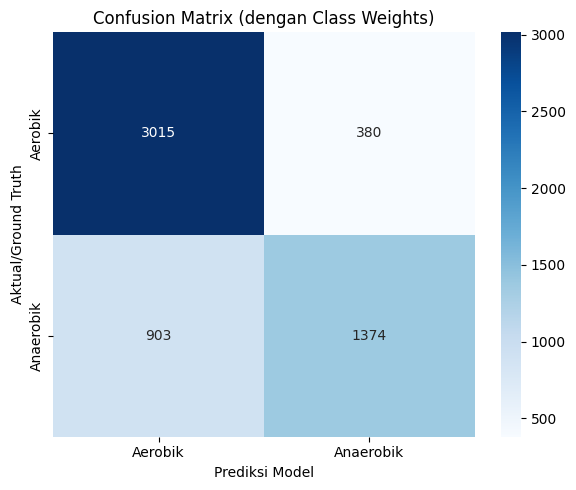

In [10]:
model_weighted = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Menggunakan Adam optimizer dengan gradient clipping (clipnorm)
# clipnorm adalah alternatif untuk clipvalue dan terkadang lebih stabil
optimizer_weighted = Adam(learning_rate=0.001, clipnorm=1.0)

model_weighted.compile(optimizer=optimizer_weighted, loss='binary_crossentropy', metrics=['accuracy'])

# Re-instantiate callbacks for a fresh start with the weighted model training
early_stopping_weighted = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler_weighted = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

print("\nMemulai Training Model Advanced dengan Class Weights (dengan Gradient Clipping Norm)...")
history_weighted = model_weighted.fit(
    X_train,
    y_train,
    epochs=20, # Bisa diset tinggi karena ada EarlyStopping
    batch_size=16,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping_weighted, lr_scheduler_weighted],
    class_weight=class_weights_dict, # Tambahkan class_weight di sini
    verbose=1
)

# Evaluasi setelah melatih dengan class weights
test_loss_weighted, test_acc_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Testing (Model dengan Class Weights): {test_acc_weighted * 100:.2f}%")

y_pred_probs_weighted = model_weighted.predict(X_test)
y_pred_weighted = (y_pred_probs_weighted >= 0.5).astype(int).flatten()

print("\n--- Classification Report (dengan Class Weights) ---")
print(classification_report(y_test, y_pred_weighted, target_names=['Aerobik (0)', 'Anaerobik (1)']))

# Visualisasi Confusion Matrix setelah class weights
plt.figure(figsize=(6, 5))
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=['Aerobik', 'Anaerobik'], yticklabels=['Aerobik', 'Anaerobik'])
plt.title('Confusion Matrix (dengan Class Weights)')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual/Ground Truth')
plt.tight_layout()
plt.show()

### Pemeriksaan Integritas Data (NaN/Inf)

Karena model terus-menerus menghasilkan `loss: nan`, ini bisa jadi indikasi adanya nilai `NaN` atau `inf` di data input atau target yang digunakan untuk training. Mari kita periksa `X_train` dan `y_train`.

In [ ]:
# Verifikasi integritas data setelah seluruh preprocessing
print(f"NaN di X_train: {np.isnan(X_train).sum()}")
print(f"Inf di X_train: {np.isinf(X_train).sum()}")
print(f"NaN di y_train: {np.isnan(y_train.astype(float)).sum()}")
print(f"Inf di y_train: {np.isinf(y_train.astype(float)).sum()}")

if (np.isnan(X_train).sum() > 0 or np.isinf(X_train).sum() > 0 or
        np.isnan(y_train.astype(float)).sum() > 0 or np.isinf(y_train.astype(float)).sum() > 0):
    print("\nPERINGATAN: Ditemukan nilai NaN atau Inf di data training. Ini perlu diatasi!")
else:
    print("\nData training bersih — tidak ada NaN atau Inf.")


NaN di X_train: 0
Inf di X_train: 0
NaN di y_train: 0
Inf di y_train: 0

Tidak ditemukan nilai NaN atau Inf di data training. Masalah mungkin ada di hyperparameter atau arsitektur model.
